In [ ]:
%load_ext autoreload
%autoreload 2
%cd ../..

In [2]:
from postprocess.ia.eval import (
    answers_for_model,
    fm_scores_for_model,
    metrics_for_model,
    metrics_for_models
)

def pivot_fm_scores(df):
    df_long = df.melt(
        id_vars=['patient', 'fm_item'],
        value_vars=['pred_score', 'gt_score'],
        var_name='score_type',
        value_name='score'
    )
    df_long['col'] = df_long['score_type'] + "_" + df_long['patient']
    out = df_long.pivot(index="fm_item", columns="col", values="score")
    return out


def pivot_answers(df):
    melted_df = df.melt(
        id_vars=['patient', 'qid'],
        value_vars=['answer'],
        var_name='answer_type',
    )
    melted_df.drop(columns=['answer_type'], inplace=True)
    melted_df.rename({'value': 'answer'}, axis=1, inplace=True)
    out = (
        melted_df
        .pivot(index="qid", columns="patient", values="answer")
        .add_suffix("_answer")
    )
    return out

# Qwen2.5-VL-72b

In [3]:
import pandas as pd

from data.utils_strokerehab import HEALTHY_PATIENTS, MILD_PATIENTS, MODERATE_PATIENTS, SEVERE_PATIENTS, DataPaths

In [4]:
MODEL = "qwen2_5_vl_72b"

TEST_PATIENTS = (
    'C00012,C00015,C00019,C00025,'
    'S0001,S00010,S00011,S00012,S00013,'
    'S00016,S00017,S00018,S00019,S0002,'
    'S00020,S00021,S00023,S00026,S00028,'
    'S00029,S0003,S00031,S00034,S0004,'
    'S0005,S0006,S0007,S0008,S0009'
).split(',')

HEALTHY = [p for p in TEST_PATIENTS if p in HEALTHY_PATIENTS.split(',')]
MILD = [p for p in TEST_PATIENTS if p in MILD_PATIENTS.split(',')]
MODERATE = [p for p in TEST_PATIENTS if p in MODERATE_PATIENTS.split(',')]
SEVERE = [p for p in TEST_PATIENTS if p in SEVERE_PATIENTS.split(',')]


PATIENT_ORDER = HEALTHY + MILD + MODERATE + SEVERE


In [5]:
pivot_table = pivot_answers(answers_for_model(MODEL, tasks=("strokerehab_ia4_3_30","strokerehab_ia4_31_33"), drop_parsed=False))

In [6]:
def fm_item_section(fm_item):
    if fm_item <= 2 or fm_item == 18 or fm_item > 33:
        return "N/A"
    elif fm_item <= 8:
        return "Arm: Flexor Synergy"
    elif fm_item <= 11:
        return "Arm: Extensor Synergy"
    elif fm_item <= 14:
        return "Arm: Movement Combining Synergy"
    elif fm_item <= 17:
        return "Arm: Movement Out of Synergy"
    elif fm_item <= 23:
        return "Wrist"
    elif fm_item <= 30:
        return "Hand"
    else:
        return "Coordination/Speed"

In [7]:
def process_fm_scores(fm_scores):
    fm_scores['fm_item'] = fm_scores.index.astype(int)
    fm_scores = fm_scores.melt(id_vars=['fm_item'], value_vars=fm_scores.columns.difference(['fm_item']))
    fm_scores['gt_or_pred'] = fm_scores['col'].apply(lambda x: 'gt' if x.startswith('gt_') else 'pred')
    fm_scores['patient'] = fm_scores['col'].apply(lambda x: x.replace('gt_score_','').replace('pred_score_',''))
    fm_scores.drop(columns=['col'], inplace=True)
    fm_scores["fm_section"] = fm_scores['fm_item'].apply(fm_item_section)

    gt_fm_scores = fm_scores[fm_scores['gt_or_pred'] == 'gt'].drop(columns=['gt_or_pred'])
    pred_fm_scores = fm_scores[fm_scores['gt_or_pred'] == 'pred'].drop(columns=['gt_or_pred'])
    merged_fm_scores = pd.merge(
        gt_fm_scores,
        pred_fm_scores,
        on=['fm_item', 'patient', 'fm_section'],
        suffixes=('_gt', '_pred')
    )
    merged_fm_scores = merged_fm_scores.rename(columns={'value_gt': 'score', 'value_pred': 'pred_score'})
    merged_fm_scores = merged_fm_scores[['patient', 'fm_item', 'fm_section', 'score', 'pred_score']].copy()
    merged_fm_scores['patient_cohort'] = merged_fm_scores['patient'].apply(
        lambda x: (
            "Healthy" if x in HEALTHY else
            "Mild" if x in MILD else
            "Moderate" if x in MODERATE else
            "Severe" if x in SEVERE else
            "Unknown"
        )
    )
    return merged_fm_scores

In [8]:
# FM scoring abilities between granular question-answering and chain-of-thought

scores_qa = pivot_fm_scores(fm_scores_for_model(
    MODEL,
    tasks=("strokerehab_ia2_3_30","strokerehab_ia2_31_33"),
    questions_csv_path=DataPaths.IA_QUESTIONS_PATH2,
))[['gt_score_' + p for p in PATIENT_ORDER] + ['pred_score_' + p for p in PATIENT_ORDER]]
scores_qa = process_fm_scores(scores_qa)
metrics_qa = metrics_for_model(MODEL, tasks=("strokerehab_ia2_3_30","strokerehab_ia2_31_33"), questions_csv_path=DataPaths.IA_QUESTIONS_PATH2)

scores_cot = pivot_fm_scores(fm_scores_for_model(
    MODEL,
    tasks=("strokerehab_ia4_3_30","strokerehab_ia4_31_33"),
    questions_csv_path=DataPaths.IA_QUESTIONS_PATH4,
))[['gt_score_' + p for p in PATIENT_ORDER] + ['pred_score_' + p for p in PATIENT_ORDER]]
scores_cot = process_fm_scores(scores_cot)
metrics_cot = metrics_for_model(MODEL, tasks=("strokerehab_ia4_3_30","strokerehab_ia4_31_33"), questions_csv_path=DataPaths.IA_QUESTIONS_PATH4)

In [ ]:
print(metrics_qa)

{'accuracy': 0.39080459770114945, 'apd': 26.03448275862069, 'mtsd': 21.344827586206897}


In [ ]:
{'accuracy': 0.39080459770114945, 'apd': 26.03448275862069, 'mtsd': 21.344827586206897}
{'accuracy': 0.39425287356321836, 'apd': 20.620689655172413, 'mtsd': 13.793103448275861}

{'accuracy': 0.39425287356321836,
 'apd': 20.620689655172413,
 'mtsd': 13.793103448275861}

In [11]:
### Missing videos: give benefit of the doubt
# C00012 missed 15R and hence 18: plug both item's score and pred_score as 2
# S0002 missed 21: plug pred_score as GT

# S0002 26: "this image does not provide enough information" -> Say the model is wrong
# S00021 33: why is this NA?


In [17]:
scores_cot['fm_section'].value_counts()

fm_section
Hand                               203
Arm: Flexor Synergy                174
Wrist                              145
Arm: Extensor Synergy               87
Arm: Movement Out of Synergy        87
Arm: Movement Combining Synergy     87
Coordination/Speed                  87
N/A                                 29
Name: count, dtype: int64

In [29]:
import numpy as np
finger_filter = scores_cot['fm_item'].between(22, 22)
finger_df = scores_cot[finger_filter]
np.abs(finger_df['score'] - finger_df['pred_score']).value_counts()

1    20
0     8
2     1
Name: count, dtype: Int64

In [ ]:
import numpy as np
big_error_filter = np.abs(scores_cot['score'] - scores_cot['pred_score']) == 2
arm_filter = scores_cot['fm_section'].str.contains("Arm")
severe_filter = scores_cot['patient_cohort'] == "Severe"
scores_cot[big_error_filter & arm_filter & severe_filter]

In [12]:
len(scores_qa)

899

In [13]:
# Fix C00012 for both scores_qa and scores_cot
scores_qa.loc[(scores_qa['patient'] == 'C00012') & (scores_qa['fm_item'].isin([15,18])), 'pred_score'] = 2
scores_cot.loc[(scores_cot['patient'] == 'C00012') & (scores_cot['fm_item'].isin([15,18])), 'pred_score'] = 2
scores_cot.loc[(scores_cot['patient'] == 'C00012') & (scores_cot['fm_item'].isin([15,18])), 'score'] = 2
scores_qa.loc[(scores_qa['patient'] == 'C00012') & (scores_qa['fm_item'].isin([15,18])), 'score'] = 2

In [ ]:
scores_qa[scores_qa['patient'] == 'S00010']

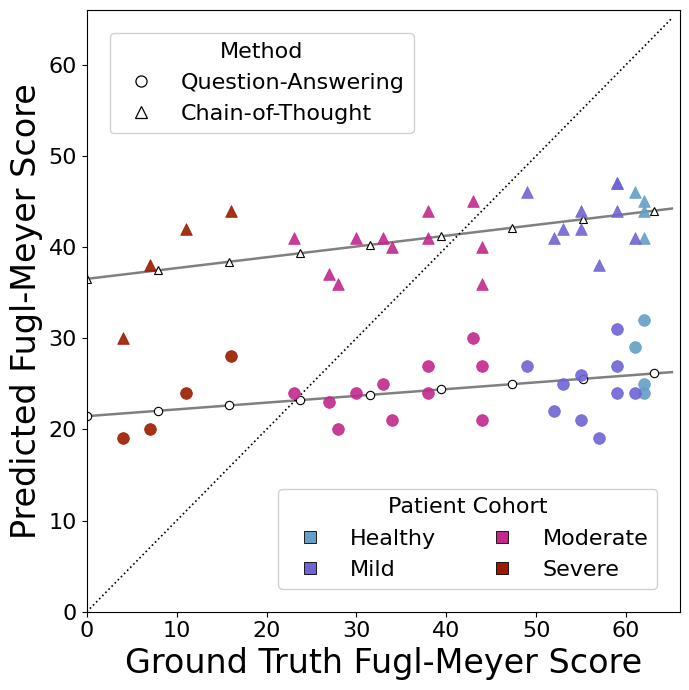

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import linregress
from typing import Dict, Tuple

def _summarize(df: pd.DataFrame, label: str) -> pd.DataFrame:
    agg = (
        df.groupby(["patient", "patient_cohort"], as_index=False)[["score", "pred_score"]]
          .sum()
          .rename(columns={"score": "gt_total", "pred_score": "pred_total"})
    )
    agg["method"] = label
    return agg

def _fit_line(x: np.ndarray, y: np.ndarray) -> Tuple[float, float, float, float]:
    lr = linregress(x, y, alternative='greater')   # slope/intercept/one-sided p for slope>0
    # Predictive R^2 (y_pred = y, y_true = x)
    sst = np.sum((x - np.mean(x))**2)
    sse = np.sum((x - y)**2)
    r2_pred = np.nan if sst <= 0 else 1 - sse/sst  # standard coefficient of determination
    return lr.slope, lr.intercept, r2_pred, lr.pvalue

def compare_totals_plot(scores_qa: pd.DataFrame, scores_cot: pd.DataFrame, save_fig: str = None):
    # --- summarize & concat ---
    qa = _summarize(scores_qa, "QA")
    cot = _summarize(scores_cot, "COT")
    df = pd.concat([qa, cot], ignore_index=True)

    # --- colors by COHORT ---
    cohorts = sorted(df["patient_cohort"].astype(str).unique())

    cohort_style: Dict[str, Tuple[str, str]] = {
        "Healthy":  ("#649FC7", "D"),  # dark blue
        "Mild":     ("#6F64D4", "o"),  # violet
        "Moderate": ("#C2288C", "o"),  # rosy pink
        "Severe":   ("#9C1A00", "o"),  # brick red
    }
    cohort_to_color = {c: color for c, (color, _) in cohort_style.items()}

    # --- markers by METHOD (internal keys) ---
    method_to_marker = {"QA": "o", "COT": "^"}  # circle for QA, triangle for COT
    method_to_style  = {"QA": dict(ls="-", lw=1.8), "COT": dict(ls="-", lw=1.8)}

    # --- display name mapping ---
    method_display = {"QA": "Question-Answering", "COT": "Chain-of-Thought"}

    # --- plotting ---
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlabel("Ground Truth Fugl-Meyer Score", fontsize=24)
    ax.set_ylabel("Predicted Fugl-Meyer Score", fontsize=24)

    # Slight jitter in x so QA/COT for same patient don't sit exactly atop each other (kept as zeros by default)
    jitter = {"QA": -0.0, "COT": +0.0}

    # Points: color by COHORT, marker by METHOD
    for method in ["QA", "COT"]:
        dsub = df[df["method"] == method]
        for cohort in cohorts:
            csub = dsub[dsub["patient_cohort"].astype(str) == cohort]
            if csub.empty:
                continue
            x = csub["gt_total"].to_numpy() + jitter[method]
            y = csub["pred_total"].to_numpy()
            ax.scatter(
                x, y,
                marker=method_to_marker[method],
                s=70, alpha=0.9,
                color=cohort_to_color.get(cohort, "#444444"),
                linewidths=0.6,
                zorder=3
            )

    # Reference y=x
    lim = max(df["gt_total"].max(), df["pred_total"].max()) * 1.05
    ax.plot([0, lim], [0, lim], linestyle=":", linewidth=1.2, color="black")
    ax.set_xlim(0, 66)
    ax.set_ylim(0, 66)
    ax.tick_params(labelsize=16)

    # Fit lines (kept), but remove text boxes; collect per-method R^2 for legend
    xx = np.linspace(0, lim, 100)
    method_r2: Dict[str, float] = {}
    for method in ["COT", "QA"]:  # draw COT last so it isn't occluded
        dsub = df[df["method"] == method]
        slope, intercept, r2, pval = _fit_line(
            dsub["gt_total"].to_numpy(),
            dsub["pred_total"].to_numpy()
        )
        method_r2[method] = r2
        yy = slope * xx + intercept
        ax.plot(
            xx, yy,
            marker=method_to_marker[method], markevery=12, mfc="white",
            mec="black", mew=0.8,
            color="gray", **method_to_style[method],
            zorder=1.5
        )

    # Legends:
    # (1) Cohorts (colors)
    cohort_handles = [
        Line2D([0], [0], marker="s", linestyle="", markersize=8,
               markerfacecolor=cohort_to_color.get(c, "#444444"),
               markeredgecolor="black", markeredgewidth=0.6, label=c)
        for c in cohorts
    ]
    leg1 = ax.legend(
        handles=cohort_handles,
        title="Patient Cohort",
        fontsize=16, title_fontsize=16,
        loc="lower right",
        bbox_to_anchor=(0.98, 0.02),
        frameon=True,
        ncol=2
    )
    leg1.get_frame().set_alpha(0.9)

    # (2) Methods (marker shapes) — include R^2 in label
    method_handles = []
    for m in ["QA", "COT"]:
        # label = f"{method_display[m]} (R²={method_r2.get(m, float('nan')):.3f})"
        label = f"{method_display[m]}"
        handle = Line2D(
            [0], [0],
            marker=method_to_marker[m],
            linestyle="",
            markersize=8,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.9,
            label=label,
        )
        method_handles.append(handle)

    leg2 = ax.legend(
        handles=method_handles,
        title="Method",
        fontsize=16, title_fontsize=16,
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        frameon=True
    )
    leg2.get_frame().set_alpha(0.9)

    ax.add_artist(leg1)

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_fig, dpi=300, bbox_inches="tight")
    plt.show()


compare_totals_plot(scores_qa, scores_cot, save_fig="fm_score_comparison_qa_vs_cot.pdf")

In [ ]:
import pandas as pd
from scipy.stats import linregress
from scipy import stats

def compute_section_errors(scores_qa: pd.DataFrame, scores_cot: pd.DataFrame, scores_ones: pd.DataFrame):
    def section_errs(df: pd.DataFrame, method: str):
        results = []
        num_dropped = 0
        for section, sub in df.groupby("fm_section"):
            if len(sub) < 2:
                continue  # skip sections with too few data points

            error = (sub['score'] - sub['pred_score']).abs().to_numpy()
            # Drop nans
            num_dropped += np.isnan(error).sum()
            error = error[~np.isnan(error)]

            avg_error = error.mean()
            sem = error.std(ddof=1) / np.sqrt(len(sub))

            results.append({
                "method": method,
                "fm_section": section,
                "avg_error": avg_error,
                "std_error": sem,
                "n": len(sub),
            })
        print(f"Dropped {num_dropped} NaN errors for method {method}")

        return pd.DataFrame(results)

    qa_errs = section_errs(scores_qa, "QA")
    cot_errs = section_errs(scores_cot, "COT")
    ones_errs = section_errs(scores_ones, "ONES")

    combined_errs = pd.concat([qa_errs, cot_errs, ones_errs], ignore_index=True)
    combined_errs = combined_errs.sort_values(["fm_section", "method"])

    return combined_errs


In [27]:
scores_ones = scores_qa.copy()
scores_ones = scores_ones.assign(pred_score=1)

In [28]:
# Some videos were missing
errs = compute_section_errors(scores_qa, scores_cot, scores_ones)

Dropped 3 NaN errors for method QA
Dropped 2 NaN errors for method COT
Dropped 0 NaN errors for method ONES


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_section_bars(
    df: pd.DataFrame,
    *,
    value_col: str,                # "r" or "avg_error"
    methods: list[str] = ("QA", "COT", "ONES"),
    xlabel: str | None = None,
    title: str | None = None,
    save_fig: str | None = None,
) -> None:
    """
    Grouped HORIZONTAL bars by `fm_section` for QA vs COT.

    Required columns in df:
      - 'method'      (e.g., 'QA', 'COT')
      - 'fm_section'  (string)
      - value_col     (float)  # either 'r' (correlation) or 'avg_error'

    Notes:
      - This version **removes** the 'n=' labels.
      - For correlations, positives extend right, negatives left, with a 0 reference line.
      - For avg_error (>=0), bars extend to the right; still robust to negatives if present.
    """
    assert {"method", "fm_section", value_col}.issubset(df.columns), "Missing required columns."

    # Sensible defaults
    if xlabel is None:
        xlabel = "Pearson r" if value_col == "r" else "Average error"

    data = df.copy()

    method_colors = {
        "QA": "#e79f23",    # blue
        "COT": "#55b5e8",   # orange
        "ONES": "#919191",  # green
    }

    # Order sections by the chosen metric
    sec_order = pd.unique(data["fm_section"]).tolist()[::-1]

    # Complete grid (so missing combos appear and are skipped)
    grid = (
        pd.MultiIndex.from_product([sec_order, methods], names=["fm_section", "method"])
        .to_frame(index=False)
        .merge(data, how="left", on=["fm_section", "method"])
    )

    # Y positions and layout
    y = np.arange(len(sec_order))
    h = 0.25
    offsets = {methods[0]: +h, methods[1]: 0, methods[2]: -h}

    fig, ax = plt.subplots(figsize=(7, 7))

    # Compute x-limits with padding
    vals = grid[value_col].astype(float).values
    finite_vals = vals[np.isfinite(vals)]
    if finite_vals.size == 0:
        finite_vals = np.array([0.0])

    if "std_error" in grid.columns:
        errs = grid["std_error"].astype(float).fillna(0.0).values
        lower = vals - errs
        upper = vals + errs
        finite_lower = lower[np.isfinite(lower)]
        finite_upper = upper[np.isfinite(upper)]
        vmin = float(np.nanmin(finite_lower)) if finite_lower.size else 0.0
        vmax = float(np.nanmax(finite_upper)) if finite_upper.size else 0.0
    else:
        vmin = float(np.nanmin(finite_vals))
        vmax = float(np.nanmax(finite_vals))

    # --- padding for visual breathing room ---
    pad = 0.06 * max(1e-6, (vmax - vmin) if vmax != vmin else max(1.0, abs(vmax)))

    # For correlation: allow negative on both sides, for error: start from 0
    if value_col == "r":
        x_min = vmin - pad
    else:
        x_min = 0.0
    x_max = vmax + 2 * pad

    # Bars and tip labels
    handles = []
    labels = []

    for method in methods:
        sub = grid[grid["method"] == method].reset_index(drop=True)
        ypos = y + offsets[method]

        widths = sub[value_col].fillna(0.0).values
        bars = ax.barh(
            ypos, widths, height=h, xerr=sub['std_error'], edgecolor="black", linewidth=0.8, label=method,
            color=method_colors.get(method, "gray"),  # <--- ADD THIS
        )
        handles.append(bars)
        labels.append(method)

        # Tip labels: numeric value at bar end
        for bar, val in zip(bars, sub[value_col]):
            if pd.isna(val):
                continue
            # bar.get_width() == val
            dx = 0.02 * (x_max - x_min)
            x_tip = float(val) + (dx if val >= 0 else -dx)
            ha = "left" if val >= 0 else "right"
            # Format: correlations to 2 decimals; errors to 3 (tweak as you like)
            # txt = f"{val:0.2f}" if value_col == "r" else f"{val:0.3f}"
            # ax.text(
            #     x_tip, bar.get_y() + bar.get_height()/2,
            #     txt,
            #     ha=ha, va="center", fontsize=12,
            # )

    # Cosmetics
    if value_col == "r":
        ax.axvline(0, color="black", linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(sec_order, fontsize=16)
    ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=16)
    ax.set_xlabel(xlabel, fontsize=24)
    ax.set_xlim(x_min, x_max)

    ax.legend(handles=[h[0] for h in handles], labels=labels, title="Method", fontsize=14, title_fontsize=14, loc="lower right")
    fig.tight_layout()

    if save_fig:
        plt.savefig(save_fig, dpi=300, bbox_inches="tight")
    plt.show()


In [59]:
def abbreviate_fm_section(name: str) -> str:
    if "Arm:" in name:
        arm_section = name.split(":")[1].strip()
        abbrev = "".join([c for c in arm_section if c.isupper()])  # e.g., "Flexor Synergy" -> "FS"
        return f"Arm ({abbrev})"
    elif name == "Coordination/Speed":
        return "Coord./Speed"
    return name

In [60]:
err_to_plot = errs[errs["fm_section"] != "N/A"].copy()
err_to_plot["fm_section"] = err_to_plot["fm_section"].apply(abbreviate_fm_section)

In [61]:
def get_sort_key(row):
    key = 0
    if row['method'] == 'QA':
        key += 0
    elif row['method'] == 'COT':
        key += 1
    elif row['method'] == 'ONES':
        key += 2
    else:
        raise ValueError("Unknown method")

    # By section
    if row['fm_section'] == "Arm (FS)":
        key += 0
    elif row['fm_section'] == "Arm (ES)":
        key += 10
    elif row['fm_section'] == "Arm (MCS)":
        key += 20
    elif row['fm_section'] == "Arm (MOS)":
        key += 30
    elif row['fm_section'] == "Wrist":
        key += 40
    elif row['fm_section'] == "Hand":
        key += 50
    elif row['fm_section'] == "Coord./Speed":
        key += 60
    else:
        raise ValueError("Unknown fm_section")

    return key

In [62]:
err_to_plot['sort_key'] = err_to_plot.apply(get_sort_key, axis=1)
err_to_plot = err_to_plot.sort_values('sort_key').drop(columns=['sort_key'])

In [63]:
err_to_plot

,method,fm_section,avg_error,std_error,n
1,QA,Arm (FS),0.568966,0.039376,174
9,COT,Arm (FS),0.494253,0.039721,174
17,ONES,Arm (FS),0.712644,0.034405,174
0,QA,Arm (ES),0.620690,0.057203,87
8,COT,Arm (ES),0.781609,0.059906,87
16,ONES,Arm (ES),0.896552,0.032840,87
2,QA,Arm (MCS),0.965517,0.088723,87
10,COT,Arm (MCS),0.701149,0.076886,87
18,ONES,Arm (MCS),0.770115,0.045372,87
3,QA,Arm (MOS),1.045977,0.095205,87


/tmp/ipykernel_700508/1878390773.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=16)


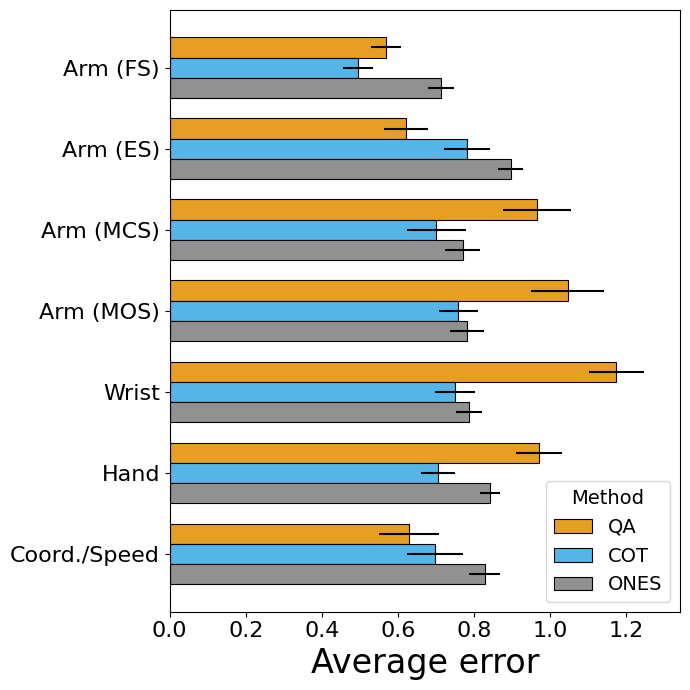

In [64]:
plot_section_bars(err_to_plot, value_col="avg_error", save_fig="fm_section_errs_qa_vs_cot.pdf")